In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [3]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

print("✅ All imports successful")

✅ All imports successful


In [4]:
CSV_PATH      = "/content/drive/MyDrive/work/dataset_with_wall_volume.csv"
IMAGE_FOLDER  = "/content/drive/MyDrive/work/data"
OUTPUT_DIR    = "/content/drive/MyDrive/work/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE    = 16
EPOCHS        = 60
RANDOM_STATE  = 42
WALL_THICK_FT = 0.75   # assumed average wall thickness (ft) — for plaster area calc

print(f"Device: {DEVICE}")

Device: cuda


In [5]:
df = pd.read_csv(CSV_PATH)
if "Cost" in df.columns:
    df.drop(columns=["Cost"], inplace=True)
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} cols")
display(df.head())

Dataset loaded: 200 rows × 18 cols


,Picture_ID,Plot_Length_ft,Plot_Width_ft,Plot_Area_sft,Builtup_Area_sft,Total_Doors,Total_Windows,Brick_Ratio,Plaster_In_Ratio,Plaster_Out_Ratio,RCC_Ratio,Room_Height_ft,No_of_Bedrooms,No_of_Toilets,Kitchen_Size_sft,Hall_Size_sft,Parking,Wall_Volume_cuft
0,114001.jpg,33.0,16.5,545.0,545,4,3,1:6,1:6,1:6,1:1:2,9.0,1,1,61.0,124.0,No,578.25
1,114002.jpg,30.0,20.0,600.0,540,4,2,1:3,1:3,1:6,1:2:4,10.0,1,1,78.0,169.0,No,669.00
2,114003.jpg,28.0,24.0,672.0,620,4,2,1:4,1:6,1:4,1:1:2,10.0,1,1,90.0,169.0,No,699.00
3,114004.jpg,26.0,20.0,520.0,480,4,4,1:3,1:5,1:6,1:1:2,10.0,1,1,65.0,163.0,No,591.00
4,114005.jpg,30.0,22.0,660.0,600,4,2,1:6,1:3,1:4,1:1:2,10.0,1,1,90.0,130.0,No,699.00


In [6]:
def _parse_ratio_parts(x):
    """'1:5' → (1.0, 5.0)  |  '1:2:4' → (1.0, 2.0)  |  bad → (1.0, 5.0)"""
    try:
        parts = [float(p) for p in str(x).split(':')]
        if len(parts) >= 2:
            return parts[0], parts[1]
    except:
        pass
    return 1.0, 5.0

for raw_col, c_col, s_col in [
    ("Brick_Ratio",       "c_brick",       "s_brick"),
    ("Plaster_In_Ratio",  "c_plaster_in",  "s_plaster_in"),
    ("Plaster_Out_Ratio", "c_plaster_out", "s_plaster_out"),
]:
    if raw_col in df.columns:
        df[[c_col, s_col]] = df[raw_col].apply(
            lambda x: pd.Series(_parse_ratio_parts(x))
        )
print("✅ Ratio parts parsed.")

✅ Ratio parts parsed.


In [7]:
HELPER_COLS = ["c_brick","s_brick","c_plaster_in","s_plaster_in","c_plaster_out","s_plaster_out"]

def ratio_avg(x):
    try:
        parts = [float(p) for p in str(x).split(':')]
        return sum(parts) / len(parts)
    except:
        return np.nan

for col in ["Brick_Ratio","Plaster_In_Ratio","Plaster_Out_Ratio","RCC_Ratio"]:
    if col in df.columns:
        df[col] = df[col].apply(ratio_avg)

df.replace({"Yes": 1, "No": 0}, inplace=True)

for col in df.columns:
    if col not in (["Picture_ID"] + HELPER_COLS):
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.fillna(df.mean(numeric_only=True), inplace=True)
print(f"✅ Preprocessing done. Shape: {df.shape}")


✅ Preprocessing done. Shape: (200, 24)


In [8]:
TARGET = "Wall_Volume_cuft"

TABULAR_COLS = [c for c in df.columns
                if c not in (["Picture_ID", TARGET] + HELPER_COLS)]

tabular_data = df[TABULAR_COLS].values
labels       = df[TARGET].values.reshape(-1, 1)

scaler_tab  = StandardScaler()
tab_scaled  = scaler_tab.fit_transform(tabular_data)

label_mean  = labels.mean()
label_std   = labels.std()
labels_norm = (labels - label_mean) / label_std

# Single shared split (same rows across ALL models for fair comparison)
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE
)
test_idx_set = set(test_idx.tolist())   # used to label rows in output CSVs

print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")
print(f"Tabular features ({len(TABULAR_COLS)}): {TABULAR_COLS}")


Train: 160 | Test: 40
Tabular features (16): ['Plot_Length_ft', 'Plot_Width_ft', 'Plot_Area_sft', 'Builtup_Area_sft', 'Total_Doors', 'Total_Windows', 'Brick_Ratio', 'Plaster_In_Ratio', 'Plaster_Out_Ratio', 'RCC_Ratio', 'Room_Height_ft', 'No_of_Bedrooms', 'No_of_Toilets', 'Kitchen_Size_sft', 'Hall_Size_sft', 'Parking']


In [9]:
def compute_materials(wall_vol, c_b, s_b, c_pi, s_pi, c_po, s_po):
    BAG, DW, MF      = 1.25, 1.33, 0.25
    IN_T, OUT_T      = 0.0417, 0.0625

    # Brickwork quantities
    num_bricks        = wall_vol * 13.5
    mortar_dry        = wall_vol * MF * DW
    tot_b             = max(c_b + s_b, 1e-9)
    cement_brick_bags = (mortar_dry * c_b / tot_b) / BAG
    sand_brick_cuft   =  mortar_dry * s_b / tot_b

    # Plastering quantities (wall surface = vol / thickness, both faces)
    wall_area = wall_vol / WALL_THICK_FT

    def _plaster(area, thick, cp, sp):
        v   = area * thick * DW
        tot = max(cp + sp, 1e-9)
        return (v * cp / tot) / BAG, v * sp / tot

    c_in,  s_in  = _plaster(wall_area, IN_T,  c_pi, s_pi)
    c_out, s_out = _plaster(wall_area, OUT_T, c_po, s_po)

    return dict(
        Num_Bricks              = round(num_bricks,  0),
        Cement_Bags_Brickwork   = round(cement_brick_bags, 2),
        Sand_cuft_Brickwork     = round(sand_brick_cuft,   2),
        Cement_Bags_Plaster_In  = round(c_in,  2),
        Sand_cuft_Plaster_In    = round(s_in,  2),
        Cement_Bags_Plaster_Out = round(c_out, 2),
        Sand_cuft_Plaster_Out   = round(s_out, 2),
    )

def build_results_csv(df_source, row_indices, predictions, model_name):
    """
    Build a tidy output DataFrame for one model and save to CSV.
    row_indices : positional indices into df_source (e.g. np.arange(200))
    predictions : predicted wall volumes in original scale
    """
    subset = df_source.iloc[row_indices].copy().reset_index(drop=True)
    preds  = np.array(predictions).flatten()

    out = pd.DataFrame()
    if "Picture_ID" in subset.columns:
        out["Picture_ID"] = subset["Picture_ID"].values
    out["Actual_Wall_Volume_cuft"]    = subset[TARGET].values
    out["Predicted_Wall_Volume_cuft"] = preds
    out["Abs_Error_cuft"]             = np.abs(out["Actual_Wall_Volume_cuft"]
                                               - out["Predicted_Wall_Volume_cuft"])
    out["Split"] = ["Test" if i in test_idx_set else "Train" for i in row_indices]

    mat_records = []
    for i in range(len(subset)):
        row = subset.iloc[i]
        mat_records.append(compute_materials(
            preds[i],
            row.get("c_brick",       1.0),
            row.get("s_brick",       5.0),
            row.get("c_plaster_in",  1.0),
            row.get("s_plaster_in",  4.0),
            row.get("c_plaster_out", 1.0),
            row.get("s_plaster_out", 5.0),
        ))

    result = pd.concat([out, pd.DataFrame(mat_records)], axis=1)
    path   = os.path.join(OUTPUT_DIR, f"{model_name}_predictions.csv")
    result.to_csv(path, index=False)
    print(f"  ✅ Saved: {os.path.basename(path)}")
    return result

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

class FloorDataset(Dataset):
    def __init__(self, df_sub, tabular, labels_arr, transform=None):
        self.df        = df_sub.reset_index(drop=True)
        self.tab       = torch.tensor(tabular,     dtype=torch.float32)
        self.labels    = torch.tensor(labels_arr,  dtype=torch.float32)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["Picture_ID"]
        img      = Image.open(os.path.join(IMAGE_FOLDER, img_name)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.tab[idx], self.labels[idx]

train_ds = FloorDataset(df.iloc[train_idx], tab_scaled[train_idx],
                        labels_norm[train_idx], train_transform)
test_ds  = FloorDataset(df.iloc[test_idx],  tab_scaled[test_idx],
                        labels_norm[test_idx],  val_transform)
full_ds  = FloorDataset(df,                 tab_scaled,
                        labels_norm,            val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
full_loader  = DataLoader(full_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} samples | Test: {len(test_ds)} samples")


Train: 160 samples | Test: 40 samples


In [11]:
class FusionModel(nn.Module):
    def __init__(self, tab_size, dropout=0.3):
        super().__init__()

        # CNN backbone — EfficientNet-B3
        self.cnn = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

        # Freeze all CNN weights first
        for p in self.cnn.parameters():
            p.requires_grad = False

        # Unfreeze last two feature blocks for domain fine-tuning
        for name, p in self.cnn.named_parameters():
            if "features.7" in name or "features.8" in name:
                p.requires_grad = True

        # Replace classifier head (outputs 256-dim image feature)
        in_feat = self.cnn.classifier[1].in_features
        self.cnn.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_feat, 256),
            nn.ReLU(),
        )

        # Tabular branch (outputs 128-dim feature)
        self.tab_net = nn.Sequential(
            nn.Linear(tab_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),      nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout / 2),
        )

        # Fusion head  (256 + 128 → 1)
        self.fusion = nn.Sequential(
            nn.Linear(384, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256,  64), nn.ReLU(),
            nn.Linear( 64,   1),
        )

    def forward(self, img, tab):
        return self.fusion(
            torch.cat([self.cnn(img), self.tab_net(tab)], dim=1)
        )

model = FusionModel(tab_scaled.shape[1]).to(DEVICE)

cnn_backbone_params = [p for n, p in model.cnn.named_parameters()
                       if p.requires_grad and "classifier" not in n]
other_params = (list(model.cnn.classifier.parameters()) +
                list(model.tab_net.parameters()) +
                list(model.fusion.parameters()))

optimizer = optim.Adam([
    {"params": cnn_backbone_params, "lr": 1e-4},  # slow fine-tune
    {"params": other_params,        "lr": 5e-4},  # faster for new layers
])
loss_fn   = nn.HuberLoss(delta=1.0)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ FusionModel ready | Trainable params: {trainable:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 196MB/s]


✅ FusionModel ready | Trainable params: 4,423,675


In [12]:
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    t_loss = 0.0
    for imgs, tabs, ys in train_loader:
        imgs, tabs, ys = imgs.to(DEVICE), tabs.to(DEVICE), ys.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(imgs, tabs), ys)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    train_losses.append(t_loss / len(train_loader))

    # ── Validate ──
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for imgs, tabs, ys in test_loader:
            imgs, tabs, ys = imgs.to(DEVICE), tabs.to(DEVICE), ys.to(DEVICE)
            v_loss += loss_fn(model(imgs, tabs), ys).item()
    val_losses.append(v_loss / len(test_loader))

    scheduler.step()

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")


  Epoch  10/60 | Train: 0.0720 | Val: 0.0249
  Epoch  20/60 | Train: 0.0649 | Val: 0.0322
  Epoch  30/60 | Train: 0.0514 | Val: 0.0270
  Epoch  40/60 | Train: 0.0392 | Val: 0.0348
  Epoch  50/60 | Train: 0.0475 | Val: 0.0316
  Epoch  60/60 | Train: 0.0304 | Val: 0.0357


In [13]:
model.eval()
cnn_preds_raw, cnn_true_raw = [], []
with torch.no_grad():
    for imgs, tabs, ys in test_loader:
        imgs, tabs = imgs.to(DEVICE), tabs.to(DEVICE)
        cnn_preds_raw.extend(model(imgs, tabs).cpu().numpy())
        cnn_true_raw.extend(ys.numpy())

cnn_preds_test = np.array(cnn_preds_raw).flatten() * label_std + label_mean
cnn_true_test  = np.array(cnn_true_raw).flatten()  * label_std + label_mean

cnn_mae = mean_absolute_error(cnn_true_test, cnn_preds_test)
cnn_r2  = r2_score(cnn_true_test, cnn_preds_test)
print(f"CNN Fusion (EfficientNet-B3) → MAE: {cnn_mae:.2f} cuft | R²: {cnn_r2:.4f} | Acc: {cnn_r2*100:.2f}%")


CNN Fusion (EfficientNet-B3) → MAE: 39.51 cuft | R²: 0.9183 | Acc: 91.83%


In [14]:
model.eval()
all_cnn_preds = []
with torch.no_grad():
    for imgs, tabs, _ in full_loader:
        imgs, tabs = imgs.to(DEVICE), tabs.to(DEVICE)
        all_cnn_preds.extend(model(imgs, tabs).cpu().numpy())

all_cnn_preds_real = np.array(all_cnn_preds).flatten() * label_std + label_mean

print("Saving CNN CSV...")
cnn_csv = build_results_csv(df, np.arange(len(df)), all_cnn_preds_real,
                             "CNN_EfficientNetB3_Fusion")

Saving CNN CSV...
  ✅ Saved: CNN_EfficientNetB3_Fusion_predictions.csv


In [15]:
X       = df[TABULAR_COLS].copy()
y       = df[TARGET].copy()
X_train = X.iloc[train_idx];  X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx];  y_test = y.iloc[test_idx]
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (160, 16) | X_test: (40, 16)


In [16]:
xgb_model = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=False)

xgb_pred_test = xgb_model.predict(X_test)
xgb_pred_full = xgb_model.predict(X)
xgb_mae = mean_absolute_error(y_test, xgb_pred_test)
xgb_r2  = r2_score(y_test, xgb_pred_test)
print(f"XGBoost                      → MAE: {xgb_mae:.2f} cuft | R²: {xgb_r2:.4f} | Acc: {xgb_r2*100:.2f}%")

print("Saving XGBoost CSV...")
xgb_csv = build_results_csv(df, np.arange(len(df)), xgb_pred_full, "XGBoost")


XGBoost                      → MAE: 17.53 cuft | R²: 0.9775 | Acc: 97.75%
Saving XGBoost CSV...
  ✅ Saved: XGBoost_predictions.csv


In [17]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=600, learning_rate=0.03, num_leaves=31,
    max_depth=-1, random_state=RANDOM_STATE, verbose=-1,
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

lgb_pred_test = lgb_model.predict(X_test)
lgb_pred_full = lgb_model.predict(X)
lgb_mae = mean_absolute_error(y_test, lgb_pred_test)
lgb_r2  = r2_score(y_test, lgb_pred_test)
print(f"LightGBM                     → MAE: {lgb_mae:.2f} cuft | R²: {lgb_r2:.4f} | Acc: {lgb_r2*100:.2f}%")

print("Saving LightGBM CSV...")
lgb_csv = build_results_csv(df, np.arange(len(df)), lgb_pred_full, "LightGBM")


LightGBM                     → MAE: 39.63 cuft | R²: 0.8910 | Acc: 89.10%
Saving LightGBM CSV...
  ✅ Saved: LightGBM_predictions.csv


In [18]:
cat_model = CatBoostRegressor(
    iterations=600, learning_rate=0.03, depth=6,
    random_seed=RANDOM_STATE, verbose=0,
)
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test))

cat_pred_test = cat_model.predict(X_test)
cat_pred_full = cat_model.predict(X)
cat_mae = mean_absolute_error(y_test, cat_pred_test)
cat_r2  = r2_score(y_test, cat_pred_test)
print(f"CatBoost                     → MAE: {cat_mae:.2f} cuft | R²: {cat_r2:.4f} | Acc: {cat_r2*100:.2f}%")

print("Saving CatBoost CSV...")
cat_csv = build_results_csv(df, np.arange(len(df)), cat_pred_full, "CatBoost")


CatBoost                     → MAE: 22.48 cuft | R²: 0.9593 | Acc: 95.93%
Saving CatBoost CSV...
  ✅ Saved: CatBoost_predictions.csv


In [19]:
results_df = pd.DataFrame({
    "Model":        ["CNN Fusion (EfficientNet-B3)", "XGBoost", "LightGBM", "CatBoost"],
    "MAE (cuft)":   [cnn_mae, xgb_mae, lgb_mae, cat_mae],
    "R² Score":     [cnn_r2,  xgb_r2,  lgb_r2,  cat_r2],
    "Accuracy (%)": [cnn_r2*100, xgb_r2*100, lgb_r2*100, cat_r2*100],
}).sort_values("R² Score", ascending=False).reset_index(drop=True)

print("\n" + "="*55)
print("           MODEL COMPARISON (Test Set)")
print("="*55)
display(results_df)
results_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)



           MODEL COMPARISON (Test Set)


,Model,MAE (cuft),R² Score,Accuracy (%)
0,XGBoost,17.530311,0.977511,97.751102
1,CatBoost,22.483136,0.959259,95.925904
2,CNN Fusion (EfficientNet-B3),39.508591,0.918343,91.834284
3,LightGBM,39.632479,0.891012,89.101158


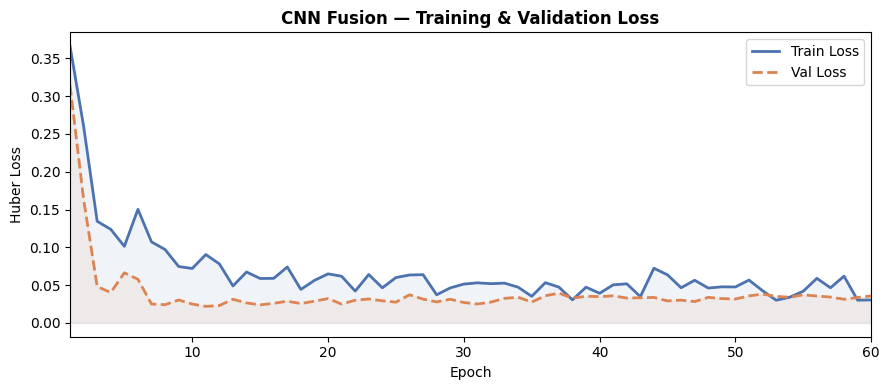

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, EPOCHS+1), train_losses, lw=2, color="#4C72B0", label="Train Loss")
ax.plot(range(1, EPOCHS+1), val_losses,   lw=2, color="#DD8452", ls="--", label="Val Loss")
ax.fill_between(range(1, EPOCHS+1), train_losses, alpha=0.08, color="#4C72B0")
ax.fill_between(range(1, EPOCHS+1), val_losses,   alpha=0.08, color="#DD8452")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss")
ax.set_title("CNN Fusion — Training & Validation Loss", fontweight="bold")
ax.legend()
ax.set_xlim(1, EPOCHS)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_cnn_loss_curve.png"), dpi=150)
plt.show()

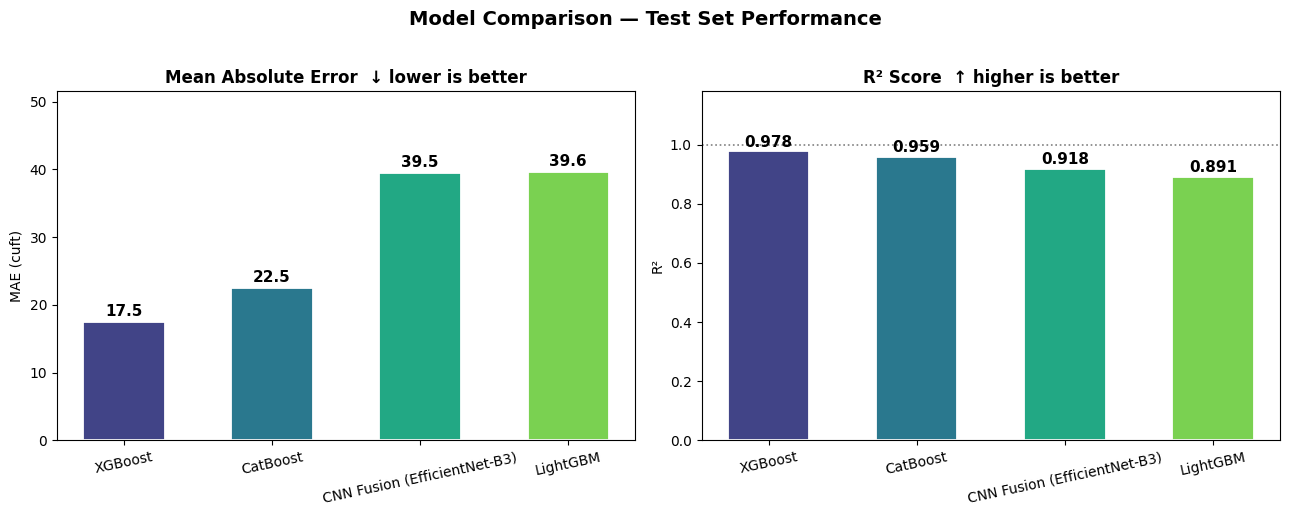

In [24]:
MODEL_NAMES = results_df["Model"]
MAES = results_df["MAE (cuft)"]
R2S = results_df["R² Score"]

# Define a color palette for the plots
PALETTE = sns.color_palette("viridis", n_colors=len(MODEL_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MAE bars
bars = axes[0].bar(MODEL_NAMES, MAES, color=PALETTE, edgecolor="white", linewidth=1.3, width=0.55)
for bar, v in zip(bars, MAES):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(MAES)*0.01,
                 f"{v:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Mean Absolute Error  ↓ lower is better", fontweight="bold")
axes[0].set_ylabel("MAE (cuft)")
axes[0].set_ylim(0, max(MAES) * 1.3)
axes[0].tick_params(axis='x', rotation=12)

# R² bars
bars = axes[1].bar(MODEL_NAMES, R2S, color=PALETTE, edgecolor="white", linewidth=1.3, width=0.55)
for bar, v in zip(bars, R2S):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].set_title("R² Score  ↑ higher is better", fontweight="bold")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0, 1.18)
axes[1].axhline(1.0, color="gray", ls=":", lw=1.2)
axes[1].tick_params(axis='x', rotation=12)

plt.suptitle("Model Comparison — Test Set Performance", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_model_comparison_bars.png"), dpi=150, bbox_inches="tight")
plt.show()

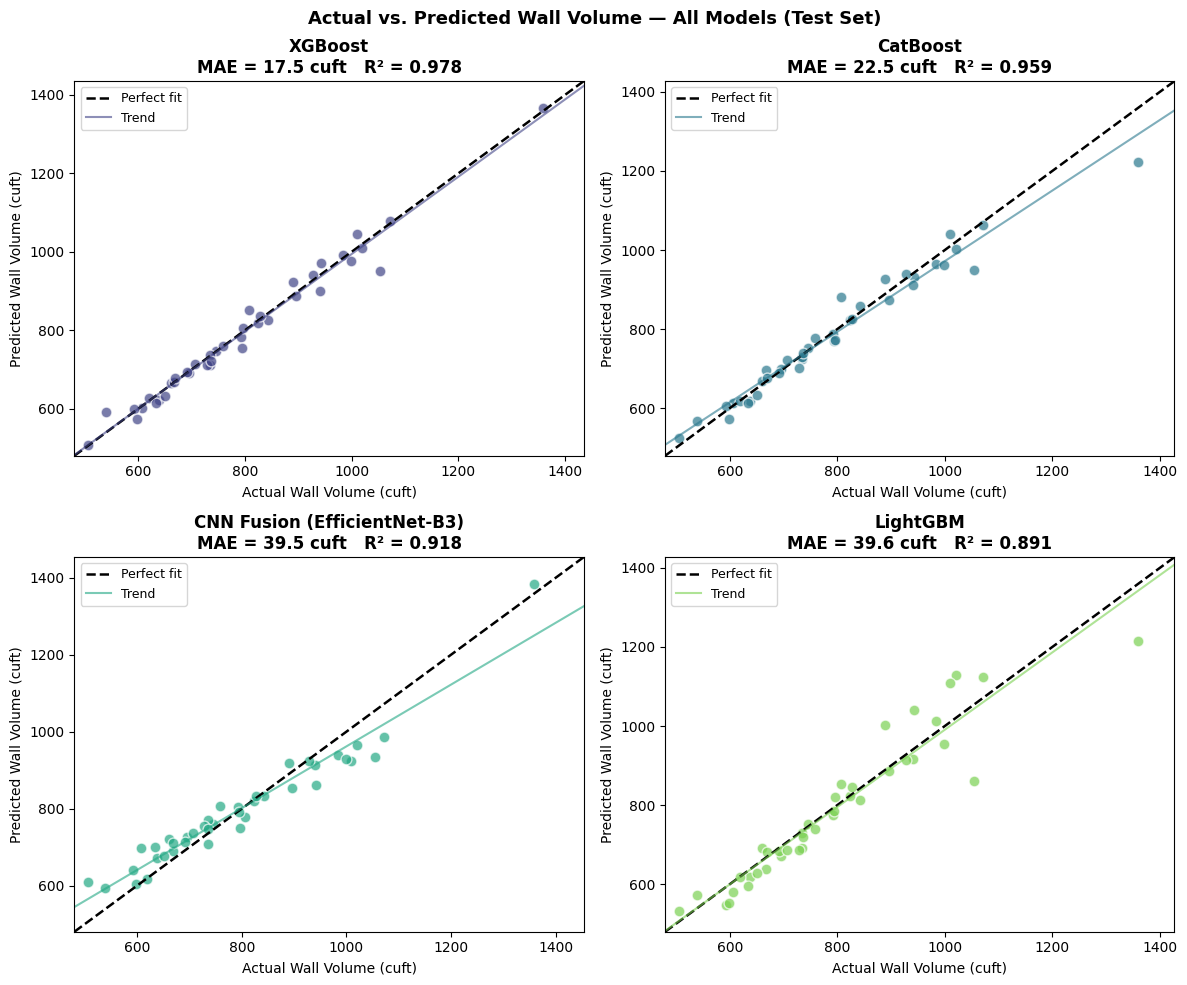

In [26]:
TEST_TRUES = [y_test, y_test, cnn_true_test, y_test]
TEST_PREDS = [xgb_pred_test, cat_pred_test, cnn_preds_test, lgb_pred_test]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, true, pred, color) in enumerate(
        zip(MODEL_NAMES, TEST_TRUES, TEST_PREDS, PALETTE)):
    ax   = axes[i]
    mn   = min(true.min(), pred.min()) * 0.95
    mx   = max(true.max(), pred.max()) * 1.05
    ax.scatter(true, pred, alpha=0.7, color=color, edgecolors="white", s=60)
    ax.plot([mn, mx], [mn, mx], "k--", lw=1.8, label="Perfect fit")
    # Add thin regression line
    z = np.polyfit(true, pred, 1)
    p = np.poly1d(z)
    x_line = np.linspace(mn, mx, 100)
    ax.plot(x_line, p(x_line), color=color, lw=1.5, ls="-", alpha=0.6, label="Trend")
    ax.set_xlabel("Actual Wall Volume (cuft)")
    ax.set_ylabel("Predicted Wall Volume (cuft)")
    ax.set_title(f"{name}\nMAE = {MAES[i]:.1f} cuft   R² = {R2S[i]:.3f}",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)

plt.suptitle("Actual vs. Predicted Wall Volume — All Models (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_actual_vs_predicted.png"), dpi=150)
plt.show()

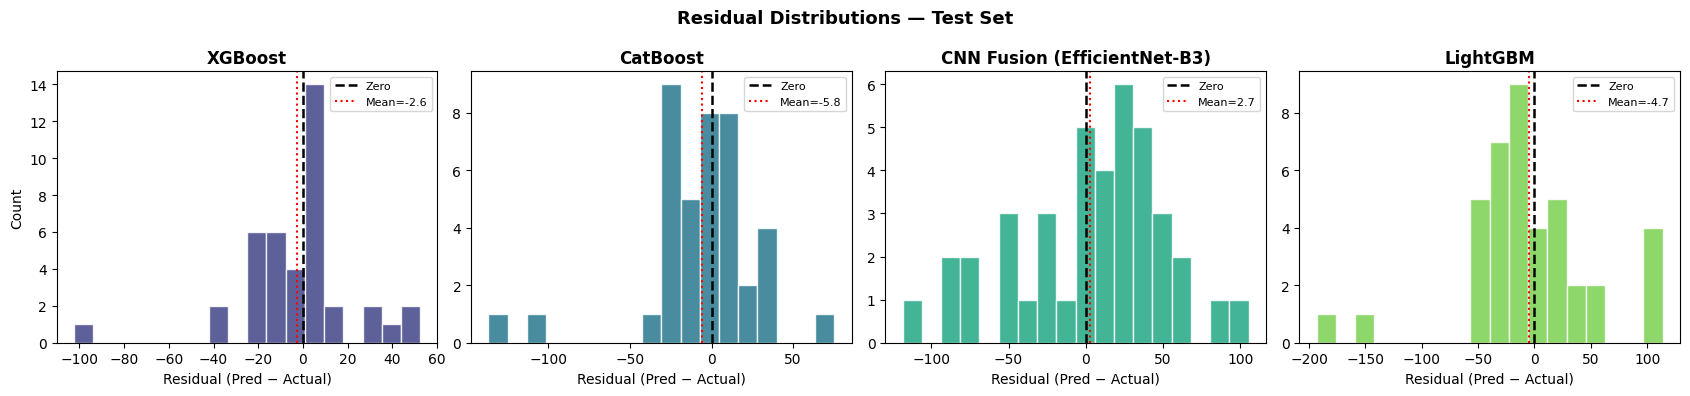

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharey=False)

for i, (name, true, pred, color) in enumerate(
        zip(MODEL_NAMES, TEST_TRUES, TEST_PREDS, PALETTE)):
    residuals = np.array(pred).flatten() - np.array(true).flatten()
    ax = axes[i]
    ax.hist(residuals, bins=18, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0,              color="black", lw=1.8, ls="--", label="Zero")
    ax.axvline(residuals.mean(), color="red", lw=1.5, ls=":",
               label=f"Mean={residuals.mean():.1f}")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Residual (Pred − Actual)")
    ax.legend(fontsize=8)
    if i == 0:
        ax.set_ylabel("Count")

plt.suptitle("Residual Distributions — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig4_residuals.png"), dpi=150)
plt.show()

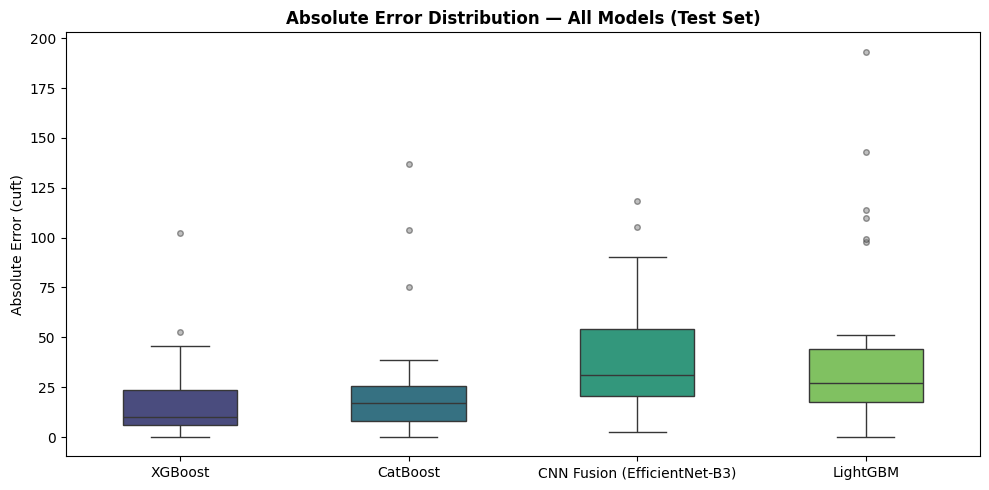

In [28]:
errors_long = pd.concat([
    pd.DataFrame({"Model": name,
                  "Absolute Error (cuft)": np.abs(
                      np.array(pred).flatten() - np.array(true).flatten())})
    for name, true, pred in zip(MODEL_NAMES, TEST_TRUES, TEST_PREDS)
])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=errors_long, x="Model", y="Absolute Error (cuft)",
            palette=PALETTE, ax=ax, width=0.5,
            flierprops=dict(marker='o', markersize=4, alpha=0.5,
                            markerfacecolor='gray'))
ax.set_title("Absolute Error Distribution — All Models (Test Set)", fontweight="bold")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig5_error_boxplots.png"), dpi=150)
plt.show()

In [30]:
print("\n" + "="*55)
print("🎉  All outputs saved to:", OUTPUT_DIR)
print("="*55)
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"  {f:<45}  {size_kb:.1f} KB")


🎉  All outputs saved to: /content/drive/MyDrive/work/results
  CNN_EfficientNetB3_Fusion_predictions.csv      20.5 KB
  CatBoost_predictions.csv                       20.5 KB
  LightGBM_predictions.csv                       20.5 KB
  XGBoost_predictions.csv                        18.5 KB
  fig1_cnn_loss_curve.png                        72.6 KB
  fig2_model_comparison_bars.png                 80.0 KB
  fig3_actual_vs_predicted.png                   267.2 KB
  fig4_residuals.png                             71.8 KB
  fig5_error_boxplots.png                        45.2 KB
  fig6_xgb_feature_importance.png                85.0 KB
  model_comparison.csv                           0.3 KB
